# VGG19 -- Lentil Disease Classification (Teacher Training)

This notebook trains a **VGG19** model for lentil disease classification as part of **Phase 1: Teacher Training on the Lentil Dataset** in a cross-crop knowledge distillation pipeline.

**Task:** 4-class classification -- Ascochyta Blight, Lentil Rust, Normal, Powdery Mildew  
**Dataset:** Lentil Augmented Dataset (4540 train / 456 val / 457 test images)

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.layers import Flatten, Dense

In [2]:
# Paths to data
train_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Train'
val_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Validation'
img_size = 224  # Standard input size for DenseNet201
batch_size = 32
seed = 123

# =====================================================================
#                     Simplified Dataset Loading
# =====================================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True
)


# Optimize data loading
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4540 files belonging to 4 classes.
Found 456 files belonging to 4 classes.


## Model Architecture -- Experiment 1 (Functional API, Frozen Base)

The pretrained **VGG19** backbone (ImageNet weights) is loaded *without* the top classification layer. All base layers are **frozen**, and a custom head is added:

`GlobalAveragePooling2D -> Dense(1024, relu) -> Dense(4, softmax)`

In [3]:
# Load base model (without top layer)
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

for layer in base_model.layers:
    layer.trainable = False 

# Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(1024, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,553,796 (78.41 MB)

 Trainable params: 529,412 (2.02 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

### Training Configuration -- Experiment 1

| Parameter | Value |
|---|---|
| Optimizer | Adam (default lr) |
| Loss | SparseCategoricalCrossentropy |
| Epochs | 20 (EarlyStopping patience=5) |
| Batch Size | 32 |
| Checkpoint | Best val_accuracy |

In [5]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=5,              # Wait for 3 epochs with no improvement
    restore_best_weights=True  # Restore model weights from the best epoch
)
checkpoint = ModelCheckpoint(
    'best_model.keras',          # File to save
    monitor='val_accuracy',    # Metric to watch
    save_best_only=True,       # Only save best model
    mode='max',                # 'max' for accuracy, 'min' for loss
    verbose=1                  # Print when saved
)

In [6]:
model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False), 
    metrics=['accuracy']
)
# Initial training with frozen base
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    shuffle = False
)

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4891 - loss: 2.5862
Epoch 1: val_accuracy improved from -inf to 0.71491, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 944s 7s/step - accuracy: 0.4898 - loss: 2.5784 - val_accuracy: 0.7149 - val_loss: 0.7436
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7363 - loss: 0.7087
Epoch 2: val_accuracy did not improve from 0.71491
142/142 ━━━━━━━━━━━━━━━━━━━━ 993s 7s/step - accuracy: 0.7364 - loss: 0.7085 - val_accuracy: 0.6491 - val_loss: 0.9197
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7608 - loss: 0.6391
Epoch 3: val_accuracy did not improve from 0.71491
142/142 ━━━━━━━━━━━━━━━━━━━━ 1022s 7s/step - accuracy: 0.7609 - loss: 0.6389 - val_accuracy: 0.7039 - val_loss: 0.7730
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8097 - loss: 0.5178
Epoch 4: val_accuracy improved from 0.71491 to 0.71930, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━

### Training Results -- Experiment 1

Loss and accuracy curves for Experiment 1 (frozen base, Functional API).

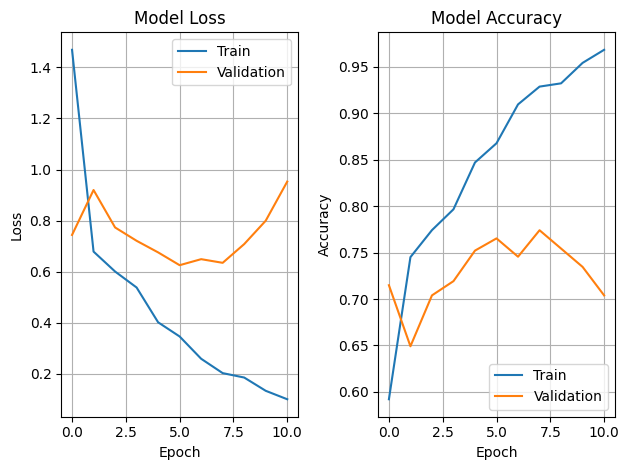

In [7]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image
# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Test",
    seed= 123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle = False
)

Found 457 files belonging to 4 classes.


In [ ]:
model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.6887 - loss: 0.9210


[0.8302846550941467, 0.7199124693870544]

In [ ]:
ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9062 - loss: 0.2451
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.7500 - loss: 0.4259
15/15 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.6887 - loss: 0.9210
Train Loss:  0.24509140849113464
Train Accuracy:  0.90625
--------------------
Validation Loss:  0.4258696436882019
Validation Accuracy:  0.75
--------------------
Test Loss:  0.8302846550941467
Test Accuracy:  0.7199124693870544


### Evaluation Metrics -- Experiment 1

Train / Validation / Test scores for Experiment 1.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list): List of class names.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Print classification report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


    # Normalize to percentages per row (true label)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step

Classification Report:

                  precision    recall  f1-score   support

Ascochyta blight       0.67      0.63      0.65       111
     Lentil Rust       0.70      0.88      0.78        95
          Normal       0.71      0.59      0.64       143
  Powdery Mildew       0.80      0.84      0.82       108

        accuracy                           0.72       457
       macro avg       0.72      0.74      0.72       457
    weighted avg       0.72      0.72      0.72       457



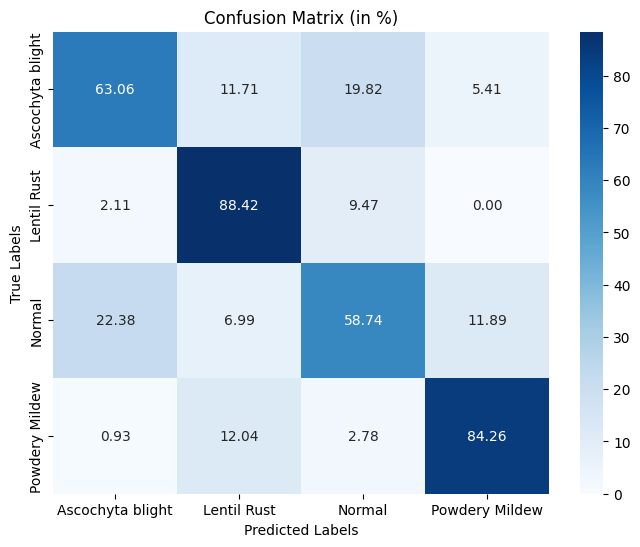

In [ ]:
# 1. Predict
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. True labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# 3. Class names
class_names =  ['Ascochyta blight', 'Lentil Rust', 'Normal', 'Powdery Mildew']

# 4. Evaluate 
evaluate_model(y_true, y_pred, class_names)

### ROC Curves -- Experiment 1

Confusion matrix and classification report followed by multiclass ROC curves for Experiment 1.

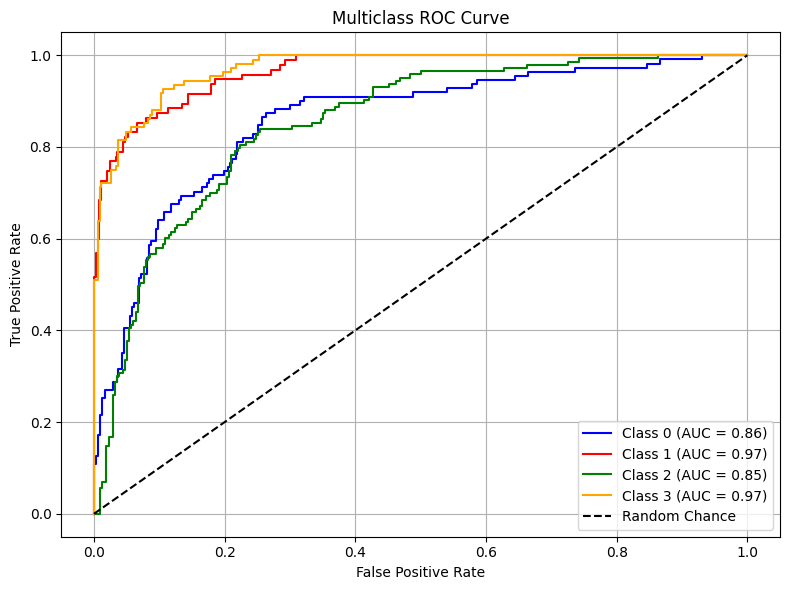

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

# One-hot encode the true labels
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# === Compute ROC and AUC for each class ===
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# === Plot all ROC curves ===
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\ROC_Curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

---

## Experiment 2 -- Sequential API, Full Fine-Tuning

In this experiment the **VGG19** backbone is loaded again, but this time **all layers are set to trainable** (`trainable = True`). A `Sequential` model is built:

`VGG19 (all trainable) -> GlobalAveragePooling2D -> Dense(4096, relu) -> Dropout(0.2) -> Dense(4, softmax)`

| Parameter | Value |
|---|---|
| Optimizer | Adam (lr=1e-4) |
| Loss | CategoricalCrossentropy |
| Epochs | 20 (EarlyStopping patience=5) |
| Labels | One-hot (`label_mode='categorical'`) |

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras import layers, models, applications, optimizers

In [ ]:
# Paths to data
train_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Train'
val_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Validation'
img_size = 224  # Standard input size for DenseNet201
batch_size = 32
seed = 123
# =====================================================================
#                     Simplified Dataset Loading
# =====================================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical' 
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical'
)


# Optimize data loading
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4540 files belonging to 4 classes.
Found 456 files belonging to 4 classes.


In [ ]:
from keras import backend as K
from keras.preprocessing import image
from keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Activation, Dropout, Flatten, Dense
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D

In [ ]:
vgg = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top=False,
    input_shape= (img_size,img_size,3))

for layer in vgg.layers:
    layer.trainable = False

vgg.trainable = True
def build_model():
    model = Sequential()
    model.add(vgg)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(4096, activation='relu')) #sigmoid
    model.add(Dropout(0.2))
    model.add(Dense(4, activation='softmax'))
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(1e-4), #1e-4
        metrics=['accuracy'])
     
    return model

model = build_model()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)                   │ (None, 7, 7, 512)           │      20,024,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4096)                │       2,101,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │          16,388 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,142,020 (84.47 MB)

 Trainable params: 2,117,636 (8.08 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=5,              # Wait for 3 epochs with no improvement
    restore_best_weights=True  # Restore model weights from the best epoch
)
checkpoint = ModelCheckpoint(
    'best_model.keras',          # File to save
    monitor='val_accuracy',    # Metric to watch
    save_best_only=True,       # Only save best model
    mode='max',                # 'max' for accuracy, 'min' for loss
    verbose=1                  # Print when saved
)

In [ ]:
# Initial training with frozen base
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping,checkpoint],
    shuffle = False
)  

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4549 - loss: 1.5671
Epoch 1: val_accuracy improved from -inf to 0.72807, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 924s 6s/step - accuracy: 0.4555 - loss: 1.5650 - val_accuracy: 0.7281 - val_loss: 0.7386
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6675 - loss: 0.8548
Epoch 2: val_accuracy did not improve from 0.72807
142/142 ━━━━━━━━━━━━━━━━━━━━ 1009s 7s/step - accuracy: 0.6676 - loss: 0.8546 - val_accuracy: 0.7105 - val_loss: 0.7838
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7346 - loss: 0.6926
Epoch 3: val_accuracy improved from 0.72807 to 0.75219, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 955s 7s/step - accuracy: 0.7348 - loss: 0.6924 - val_accuracy: 0.7522 - val_loss: 0.7304
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7884 - loss: 0.5776
Epoch 4: val_accuracy did not improve from 0.75219
142/142 ━━━━━━━━━━━━━━━━━━━━

### Training Results -- Experiment 2

Loss and accuracy curves for Experiment 2 (full fine-tuning, Sequential API).

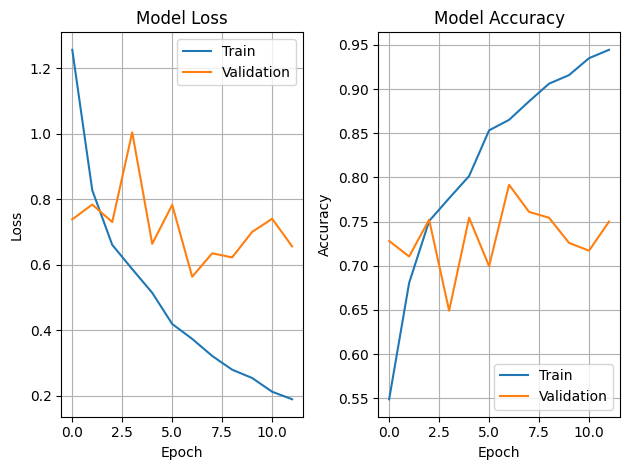

In [ ]:
# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve_1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Test",
    seed= 123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle = False,
    label_mode='categorical'
)

Found 457 files belonging to 4 classes.


In [ ]:
model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.6719 - loss: 0.9088


[0.7068651914596558, 0.7483588457107544]

In [ ]:
ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9688 - loss: 0.2643
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7812 - loss: 0.5128
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.6719 - loss: 0.9088
Train Loss:  0.26432690024375916
Train Accuracy:  0.96875
--------------------
Validation Loss:  0.5127537846565247
Validation Accuracy:  0.78125
--------------------
Test Loss:  0.7068651914596558
Test Accuracy:  0.7483588457107544


### Evaluation Metrics -- Experiment 2

Train / Validation / Test scores for Experiment 2.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels (1D array of class indices).
        y_pred (array-like): Predicted labels (1D array of class indices).
        class_names (list): List of class names.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Print classification report
    print("\nClassification Report:\n")   
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Normalize to percentages per row (true label)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix_1.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Classification Report:

                  precision    recall  f1-score   support

Ascochyta blight       0.70      0.57      0.63       111
     Lentil Rust       0.84      0.83      0.84        95
          Normal       0.67      0.69      0.68       143
  Powdery Mildew       0.81      0.94      0.87       108

        accuracy                           0.75       457
       macro avg       0.75      0.76      0.75       457
    weighted avg       0.74

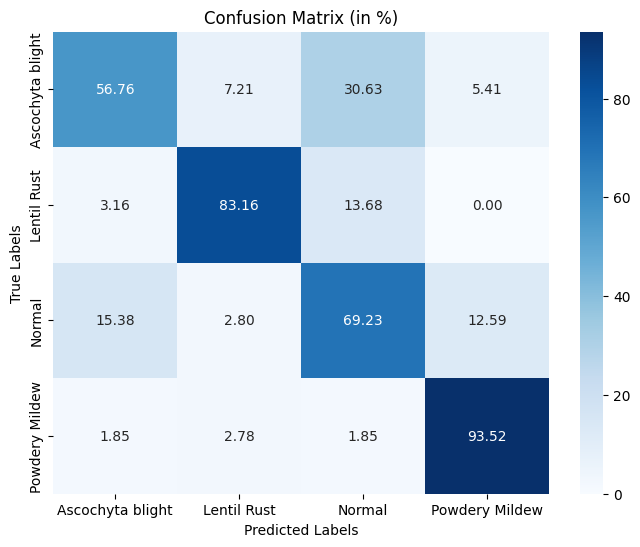

In [ ]:
# --- Get true labels and predictions from model on test set ---
y_true = []
y_pred_proba = []

for images, labels in test_ds:
    y_true.append(labels.numpy())             # Assuming labels are one-hot or class indices
    preds = model.predict(images)             # preds: [batch_size, num_classes]
    y_pred_proba.append(preds)

# Stack into arrays
y_true = np.vstack(y_true)
y_pred_proba = np.vstack(y_pred_proba)

# Convert one-hot encoded y_true to class indices (if needed)
if y_true.shape[1] > 1:
    y_true = np.argmax(y_true, axis=1)
else:
    y_true = y_true.flatten()

# Convert predicted probabilities to class indices
y_pred = np.argmax(y_pred_proba, axis=1)

# Class names
class_names = ['Ascochyta blight', 'Lentil Rust', 'Normal', 'Powdery Mildew']

# Evaluate the model
evaluate_model(y_true, y_pred, class_names)


### ROC Curves -- Experiment 2

Confusion matrix, classification report, and multiclass ROC curves for Experiment 2.

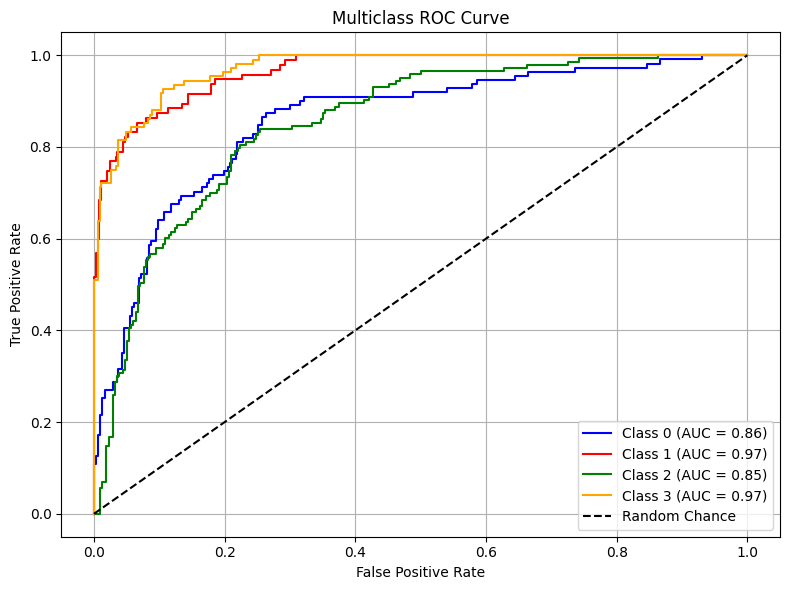

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

# One-hot encode the true labels
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# === Compute ROC and AUC for each class ===
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# === Plot all ROC curves ===
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\ROC_Curve_1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()